 <font size="10">**Notebook 06: scVI integration of Whole Embryo scRNA-seq data: part 5 (optional)**</font>
***

<div class="alert alert-info">
    
<b> <h1> ℹ️ <strong> <font size="6" color="black"> Important notebook information </font> </strong> </h1> </b>
    <hr>
    <font size="4" color="black">
        The notebook is optional  <br> <br>
        The purpose of this notebook is to visualise silhouette scores generated for selecetd scVI model and KNN graph per batch covariate used for correction for the Whole Embryo scRNA-seq data  <br> <br>
    </font>

## Import packages

In [1]:
import numpy as np
from numpy import savetxt
from numpy import loadtxt
import pandas as pd
import scanpy as sc
import scvi
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator
import tqdm
import pickle
from sklearn.metrics import homogeneity_score
from sklearn.metrics.cluster import completeness_score
from sklearn.metrics.cluster import normalized_mutual_info_score
from sklearn.metrics import silhouette_samples, silhouette_score
import datetime
import os

#to set unique date for outputs
calc_date = datetime.datetime.now()
date=calc_date.strftime('%Y-%m-%d')
#date=calc_date.strftime('%d-%m-%Y')
date = date.replace('-', '')

Global seed set to 0


## Load in anndata object and silhouette scores

In [2]:
sil_sample_dict = {}

sil_sample_dict['adata'] = sc.read('n_3_scvi_run_neighbours_30_haniffa_ID_ext_cat_10x_kit_latent_20_batch_size_3000_20220607_with_umaps.h5ad')
sil_sample_dict['scoring_dataframe'] = pd.read_csv('plot_outputs/scoring/Scoring_table_for_X_umap_neighbours_30_20220801.csv', index_col=0)
sil_sample_dict['sil_local_haniffa_ID'] = loadtxt('plot_outputs/scoring/sil_sample_scores_for_haniffa_ID_on_X_umap_neighbours_30_20220801.csv', delimiter = ',')
sil_sample_dict['sil_local_10x_kit'] = loadtxt('plot_outputs/scoring/sil_sample_scores_for_10x_kit_on_X_umap_neighbours_30_20220801.csv', delimiter = ',')

In [3]:
sil_sample_dict['adata']

AnnData object with n_obs × n_vars = 1138964 × 10000
    obs: 'dataset', 'sequencing_lane_ID', 'haniffa_ID', 'HDBR_ID', 'sequencing_type', '10x_kit', 'spatial_location', 'spatial_location_replicates', 'sort_ID', 'procedure', 'age_in_cs', 'sex', 'alignment_software', 'alignment_reference', 'cutoff_1.4826_is_doublet', 'cutoff_2_is_doublet', 'cutoff_3_is_doublet', 'nUMI', 'nGene', 'nCounts', 'percent.mito', 'percent.ribo', 'n_genes', 'n_counts', 'Z_0', 'Z_1', 'Z_2', 'Z_3', 'Z_4', 'Z_5', 'Z_6', 'Z_7', 'Z_8', 'Z_9', 'Z_10', 'Z_11', 'Z_12', 'Z_13', 'Z_14', 'Z_15', 'Z_16', 'Z_17', 'Z_18', 'Z_19', 'neighbours_15_leiden_res_0_5', 'neighbours_15_leiden_res_3', 'neighbours_20_leiden_res_0_5', 'neighbours_20_leiden_res_3', 'neighbours_25_leiden_res_0_5', 'neighbours_25_leiden_res_3', 'neighbours_30_leiden_res_0_5', 'neighbours_30_leiden_res_3'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highl

In [4]:
sil_sample_dict['scoring_dataframe']

,Basis,meta_cat,Purity_Score,Homogeneity_Score,Completeness_Score,Normalized_mutual_info_Score,Sil_global_score
0,X_umap_neighbours_30,haniffa_ID,0.440065,0.031027,0.010817,0.016042,-0.010112
1,X_umap_neighbours_30,10x_kit,0.738521,0.026503,0.004906,0.008279,0.000059


## Plot for haniffa_ID category

### Combined

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


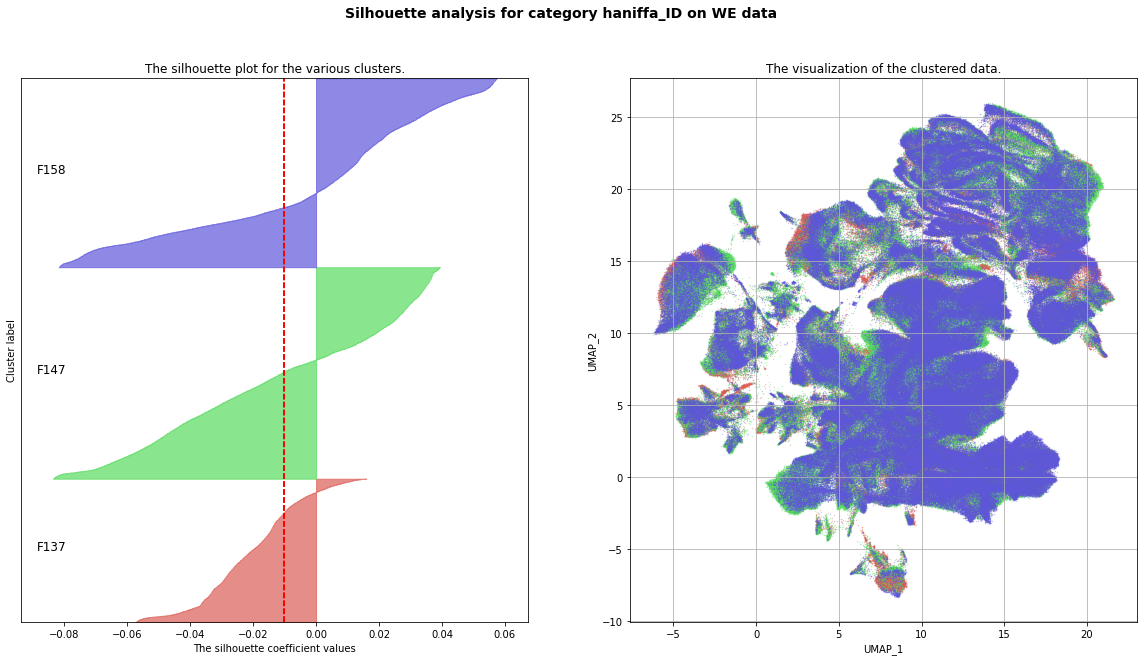

In [5]:
cat = 'haniffa_ID'
sil_score_cat = 'sil_local_haniffa_ID'
embedding = 'X_umap_neighbours_30'
sil_global = sil_sample_dict['scoring_dataframe'].loc[sil_sample_dict['scoring_dataframe']['meta_cat'] == cat, 'Sil_global_score'].values[0]


fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(20, 10)

ax1.set_xlim([sil_sample_dict[sil_score_cat].min() - abs(sil_sample_dict[sil_score_cat].mean()), abs(sil_sample_dict[sil_score_cat].max()) + abs(sil_sample_dict[sil_score_cat].mean())])
# The (n_clusters+1)*10 is for inserting blank space between silhouette
# plots of individual clusters, to demarcate them clearly.
n_clusters = len(sil_sample_dict['adata'].obs[cat].unique())
ax1.set_ylim([0, len(sil_sample_dict['adata'].obs[cat]) + (n_clusters + 1) * 10])
y_lower = 10

dict1 = dict(zip(sil_sample_dict['adata'].obs.index.to_numpy(),sil_sample_dict[sil_score_cat]))
dict2 = dict(zip(sil_sample_dict['adata'].obs.index.to_numpy(),sil_sample_dict['adata'].obs[cat].to_numpy()))

scatter = sil_sample_dict['adata'].obsm[embedding]

col_pal = sns.color_palette("hls", n_clusters)

count = 0

for i in sil_sample_dict['adata'].obs[cat].unique():
    indexes = [k for k,v in dict2.items() if v == i]
    sil_values_i = np.asarray(list({k:dict1[k] for k in indexes if k in dict1}.values()))
    sil_values_i.sort()
    size_cluster_i = sil_values_i.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color= col_pal[count]
    #color = cm.nipy_spectral(count / n_clusters)
    #color = sns.color_palette("hls", n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        sil_values_i,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )
    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(sil_sample_dict[sil_score_cat].min() - (0.5*abs(sil_sample_dict[sil_score_cat].mean())), y_lower + 0.5 * size_cluster_i, str(i), fontsize=12)
    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples
    ax1.grid(False)
    
    
    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=sil_global, color="red", linestyle="--")
    ax1.set_yticks([])
    
    
    # get scatterpoints
    df = pd.DataFrame()
    
    umap_use = sil_sample_dict['adata'].obsm[embedding][sil_sample_dict['adata'].obs[cat].isin([i])]
    scatter_coords = np.array(umap_use)
    #x_values = scatter_coords[:,0]
    #y_values = scatter_coords[:,1]
    scatter_x_values = scatter_coords[:,0]
    scatter_y_values = scatter_coords[:,1]
    df['x_points'] = scatter_x_values
    df['y_points'] = scatter_y_values
    

    
    # get centroid position
    
    centroid = np.mean(scatter_coords, axis=0)
    
    # plot the scatterplot
                       
    ax2.scatter(df['x_points'],df['y_points'], s=0.1, c = col_pal[count], alpha=0.5)
                                    
    # plot centroids
    #ax2.scatter(centroid[0], centroid[1], marker="o", c="white", alpha=1, s=200, edgecolor="k",)
                                    
    
    #for i, c in enumerate(centers):
    #    ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")
    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("UMAP_1")
    ax2.set_ylabel("UMAP_2")
    ax2.grid(True)
    plt.suptitle("Silhouette analysis for category {c} on WE data".format(c=cat),fontsize=14,fontweight="bold",)
    count+=1
    #break
    
plt.show()

### Individual

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


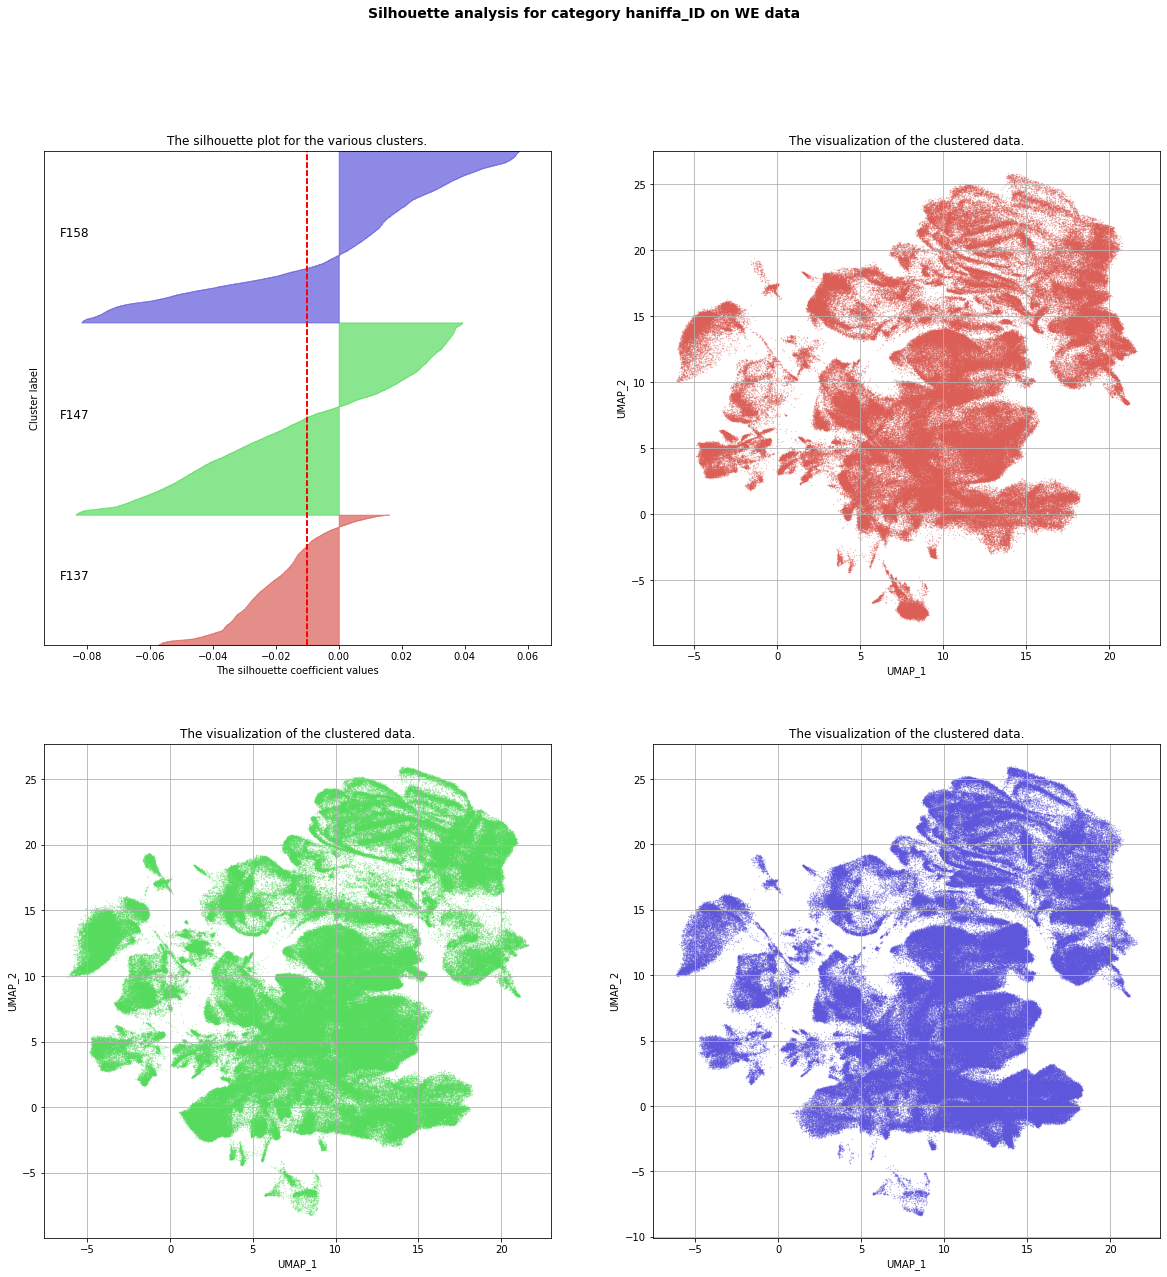

In [6]:
cat = 'haniffa_ID'
sil_score_cat = 'sil_local_haniffa_ID'
embedding = 'X_umap_neighbours_30'
sil_global = sil_sample_dict['scoring_dataframe'].loc[sil_sample_dict['scoring_dataframe']['meta_cat'] == cat, 'Sil_global_score'].values[0]


fig, [[ax1, ax2],[ax3, ax4]] = plt.subplots(2, 2)
fig.set_size_inches(20, 20)

ax1.set_xlim([sil_sample_dict[sil_score_cat].min() - abs(sil_sample_dict[sil_score_cat].mean()), abs(sil_sample_dict[sil_score_cat].max()) + abs(sil_sample_dict[sil_score_cat].mean())])
# The (n_clusters+1)*10 is for inserting blank space between silhouette
# plots of individual clusters, to demarcate them clearly.
n_clusters = len(sil_sample_dict['adata'].obs[cat].unique())
ax1.set_ylim([0, len(sil_sample_dict['adata'].obs[cat]) + (n_clusters + 1) * 10])
y_lower = 10

dict1 = dict(zip(sil_sample_dict['adata'].obs.index.to_numpy(),sil_sample_dict[sil_score_cat]))
dict2 = dict(zip(sil_sample_dict['adata'].obs.index.to_numpy(),sil_sample_dict['adata'].obs[cat].to_numpy()))

scatter = sil_sample_dict['adata'].obsm[embedding]

col_pal = sns.color_palette("hls", n_clusters)

count = 0

for i in sil_sample_dict['adata'].obs[cat].unique():
    indexes = [k for k,v in dict2.items() if v == i]
    sil_values_i = np.asarray(list({k:dict1[k] for k in indexes if k in dict1}.values()))
    sil_values_i.sort()
    size_cluster_i = sil_values_i.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color= col_pal[count]
    #color = cm.nipy_spectral(count / n_clusters)
    #color = sns.color_palette("hls", n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        sil_values_i,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )
    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(sil_sample_dict[sil_score_cat].min() - (0.5*abs(sil_sample_dict[sil_score_cat].mean())), y_lower + 0.5 * size_cluster_i, str(i), fontsize=12)
    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples
    ax1.grid(False)
    
    
    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=sil_global, color="r", linestyle="--")
    ax1.set_yticks([])
    count+=1
#
axs = [ax2,ax3,ax4]
count = 0
for i in sil_sample_dict['adata'].obs[cat].unique():

    # get scatterpoints
    df = pd.DataFrame()
    
    umap_use = sil_sample_dict['adata'].obsm[embedding][sil_sample_dict['adata'].obs[cat].isin([i])]
    scatter_coords = np.array(umap_use)
    #x_values = scatter_coords[:,0]
    #y_values = scatter_coords[:,1]
    scatter_x_values = scatter_coords[:,0]
    scatter_y_values = scatter_coords[:,1]
    df['x_points'] = scatter_x_values
    df['y_points'] = scatter_y_values
    
    # get centroid position
    
    centroid = np.mean(scatter_coords, axis=0)
    
    # plot the scatterplot
    ax = axs[count]         
    ax.scatter(df['x_points'],df['y_points'], s=0.1, c = col_pal[count], alpha=0.5)
                                    
    # plot centroids
    #ax2.scatter(centroid[0], centroid[1], marker="o", c="white", alpha=1, s=200, edgecolor="k",)
                                    
    
    #for i, c in enumerate(centers):
    #    ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")
    ax.set_title("The visualization of the clustered data.")
    ax.set_xlabel("UMAP_1")
    ax.set_ylabel("UMAP_2")
    ax.grid(True)
    plt.suptitle("Silhouette analysis for category {c} on WE data".format(c=cat),fontsize=14,fontweight="bold",)
    count+=1
    #break
    
plt.show()

## Note: There is a clear area which is not being contributed by embryo F137. Sections 02 and 04 contribute to this area. To keep in mind for further investogation

## Plot for 10x_kit category

### Combined

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


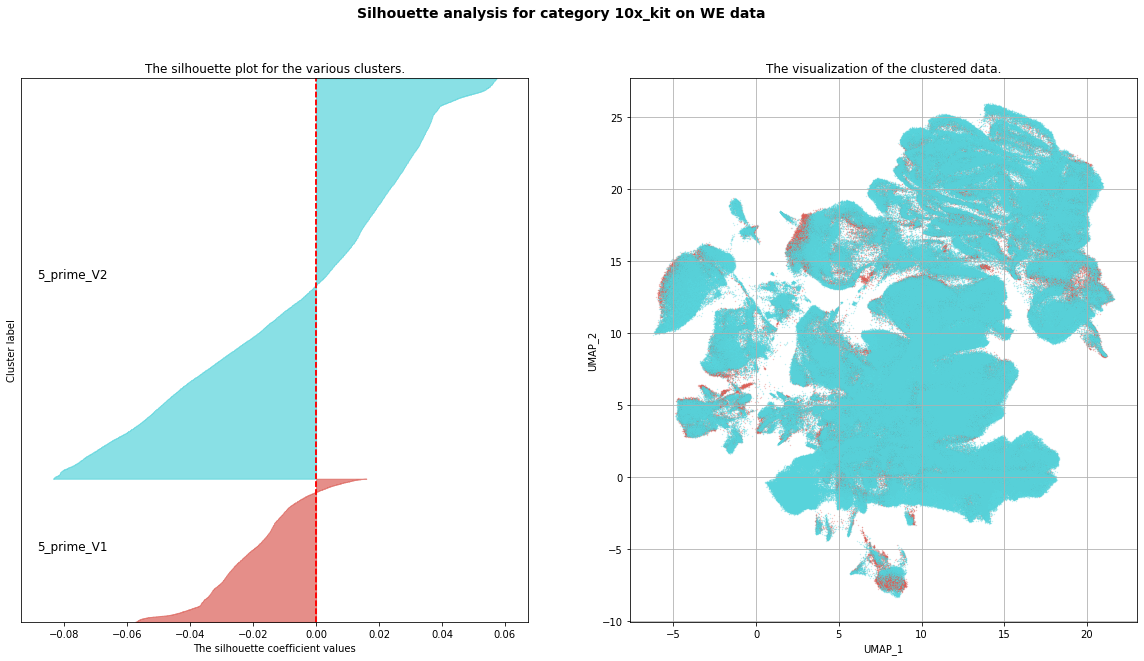

In [7]:
cat = '10x_kit'
sil_score_cat = 'sil_local_haniffa_ID'
embedding = 'X_umap_neighbours_30'
sil_global = sil_sample_dict['scoring_dataframe'].loc[sil_sample_dict['scoring_dataframe']['meta_cat'] == cat, 'Sil_global_score'].values[0]


fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(20, 10)

ax1.set_xlim([sil_sample_dict[sil_score_cat].min() - abs(sil_sample_dict[sil_score_cat].mean()), abs(sil_sample_dict[sil_score_cat].max()) + abs(sil_sample_dict[sil_score_cat].mean())])
# The (n_clusters+1)*10 is for inserting blank space between silhouette
# plots of individual clusters, to demarcate them clearly.
n_clusters = len(sil_sample_dict['adata'].obs[cat].unique())
ax1.set_ylim([0, len(sil_sample_dict['adata'].obs[cat]) + (n_clusters + 1) * 10])
y_lower = 10

dict1 = dict(zip(sil_sample_dict['adata'].obs.index.to_numpy(),sil_sample_dict[sil_score_cat]))
dict2 = dict(zip(sil_sample_dict['adata'].obs.index.to_numpy(),sil_sample_dict['adata'].obs[cat].to_numpy()))

scatter = sil_sample_dict['adata'].obsm[embedding]

col_pal = sns.color_palette("hls", n_clusters)

count = 0

for i in sil_sample_dict['adata'].obs[cat].unique():
    indexes = [k for k,v in dict2.items() if v == i]
    sil_values_i = np.asarray(list({k:dict1[k] for k in indexes if k in dict1}.values()))
    sil_values_i.sort()
    size_cluster_i = sil_values_i.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color= col_pal[count]
    #color = cm.nipy_spectral(count / n_clusters)
    #color = sns.color_palette("hls", n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        sil_values_i,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )
    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(sil_sample_dict[sil_score_cat].min() - (0.5*abs(sil_sample_dict[sil_score_cat].mean())), y_lower + 0.5 * size_cluster_i, str(i), fontsize=12)
    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples
    ax1.grid(False)
    
    
    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=sil_global, color="red", linestyle="--")
    ax1.set_yticks([])
    
    
    # get scatterpoints
    df = pd.DataFrame()
    
    umap_use = sil_sample_dict['adata'].obsm[embedding][sil_sample_dict['adata'].obs[cat].isin([i])]
    scatter_coords = np.array(umap_use)
    #x_values = scatter_coords[:,0]
    #y_values = scatter_coords[:,1]
    scatter_x_values = scatter_coords[:,0]
    scatter_y_values = scatter_coords[:,1]
    df['x_points'] = scatter_x_values
    df['y_points'] = scatter_y_values
    

    
    # get centroid position
    
    centroid = np.mean(scatter_coords, axis=0)
    
    # plot the scatterplot
                       
    ax2.scatter(df['x_points'],df['y_points'], s=0.1, c = col_pal[count], alpha=0.5)
                                    
    # plot centroids
    #ax2.scatter(centroid[0], centroid[1], marker="o", c="white", alpha=1, s=200, edgecolor="k",)
                                    
    
    #for i, c in enumerate(centers):
    #    ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")
    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("UMAP_1")
    ax2.set_ylabel("UMAP_2")
    ax2.grid(True)
    plt.suptitle("Silhouette analysis for category {c} on WE data".format(c=cat),fontsize=14,fontweight="bold",)
    count+=1
    #break
    
plt.show()

### Individual

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


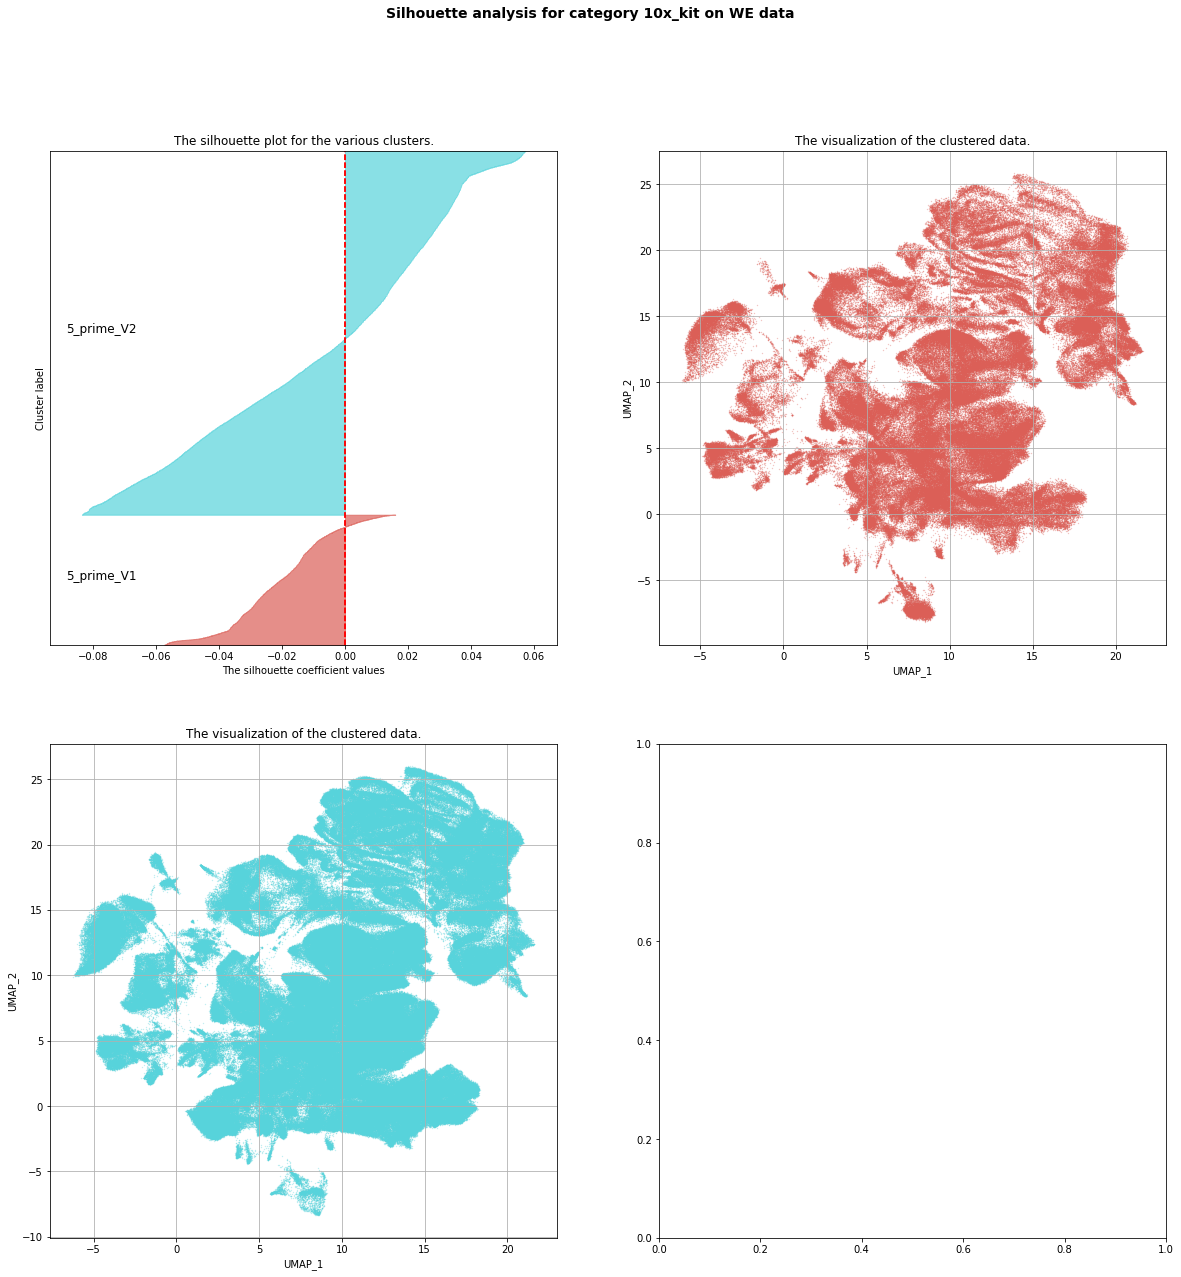

In [8]:
cat = '10x_kit'
sil_score_cat = 'sil_local_haniffa_ID'
embedding = 'X_umap_neighbours_30'
sil_global = sil_sample_dict['scoring_dataframe'].loc[sil_sample_dict['scoring_dataframe']['meta_cat'] == cat, 'Sil_global_score'].values[0]


fig, [[ax1, ax2],[ax3, ax4]] = plt.subplots(2, 2)
fig.set_size_inches(20, 20)

ax1.set_xlim([sil_sample_dict[sil_score_cat].min() - abs(sil_sample_dict[sil_score_cat].mean()), abs(sil_sample_dict[sil_score_cat].max()) + abs(sil_sample_dict[sil_score_cat].mean())])
# The (n_clusters+1)*10 is for inserting blank space between silhouette
# plots of individual clusters, to demarcate them clearly.
n_clusters = len(sil_sample_dict['adata'].obs[cat].unique())
ax1.set_ylim([0, len(sil_sample_dict['adata'].obs[cat]) + (n_clusters + 1) * 10])
y_lower = 10

dict1 = dict(zip(sil_sample_dict['adata'].obs.index.to_numpy(),sil_sample_dict[sil_score_cat]))
dict2 = dict(zip(sil_sample_dict['adata'].obs.index.to_numpy(),sil_sample_dict['adata'].obs[cat].to_numpy()))

scatter = sil_sample_dict['adata'].obsm[embedding]

col_pal = sns.color_palette("hls", n_clusters)

count = 0

for i in sil_sample_dict['adata'].obs[cat].unique():
    indexes = [k for k,v in dict2.items() if v == i]
    sil_values_i = np.asarray(list({k:dict1[k] for k in indexes if k in dict1}.values()))
    sil_values_i.sort()
    size_cluster_i = sil_values_i.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color= col_pal[count]
    #color = cm.nipy_spectral(count / n_clusters)
    #color = sns.color_palette("hls", n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        sil_values_i,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )
    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(sil_sample_dict[sil_score_cat].min() - (0.5*abs(sil_sample_dict[sil_score_cat].mean())), y_lower + 0.5 * size_cluster_i, str(i), fontsize=12)
    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples
    ax1.grid(False)
    
    
    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=sil_global, color="r", linestyle="--")
    ax1.set_yticks([])
    count+=1
#
axs = [ax2,ax3,ax4]
count = 0
for i in sil_sample_dict['adata'].obs[cat].unique():

    # get scatterpoints
    df = pd.DataFrame()
    
    umap_use = sil_sample_dict['adata'].obsm[embedding][sil_sample_dict['adata'].obs[cat].isin([i])]
    scatter_coords = np.array(umap_use)
    #x_values = scatter_coords[:,0]
    #y_values = scatter_coords[:,1]
    scatter_x_values = scatter_coords[:,0]
    scatter_y_values = scatter_coords[:,1]
    df['x_points'] = scatter_x_values
    df['y_points'] = scatter_y_values
    
    # get centroid position
    
    centroid = np.mean(scatter_coords, axis=0)
    
    # plot the scatterplot
    ax = axs[count]         
    ax.scatter(df['x_points'],df['y_points'], s=0.1, c = col_pal[count], alpha=0.5)
                                    
    # plot centroids
    #ax2.scatter(centroid[0], centroid[1], marker="o", c="white", alpha=1, s=200, edgecolor="k",)
                                    
    
    #for i, c in enumerate(centers):
    #    ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")
    ax.set_title("The visualization of the clustered data.")
    ax.set_xlabel("UMAP_1")
    ax.set_ylabel("UMAP_2")
    ax.grid(True)
    plt.suptitle("Silhouette analysis for category {c} on WE data".format(c=cat),fontsize=14,fontweight="bold",)
    count+=1
    #break
    
plt.show()

## Note: Chemistry further confirms the absense of embryo F137 specific

***
### Dependencies
Here are some information about resources and import package versions used within this script

In [21]:
%load_ext watermark
%watermark -v -m -p numpy,pandas,scanpy,anndata,scvi,sklearn

Global seed set to 0


Python implementation: CPython
Python version       : 3.9.4
IPython version      : 7.31.1

numpy  : 1.20.3
pandas : 1.4.0
scanpy : 1.7.2
anndata: 0.7.6
scvi   : 0.6.8
sklearn: 1.0.2

Compiler    : GCC 9.3.0
OS          : Linux
Release     : 4.19.0-23-cloud-amd64
Machine     : x86_64
Processor   : 
CPU cores   : 32
Architecture: 64bit

